In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries loaded!")

All libraries loaded!


In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)
matches.head()

Matches: (1095, 20)
Deliveries: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 1. Data Cleaning

In [3]:
matches['winner'].fillna('No Result', inplace=True)
matches.dropna(subset=['city'], inplace=True)

team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(team_rename)

print("Cleaning done!")
print("Total matches:", len(matches))

Cleaning done!
Total matches: 1044


## 2. Feature Engineering

In [4]:
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['team', 'wins']
win_counts = win_counts[win_counts['team'] != 'No Result']

team1_counts = matches['team1'].value_counts()
team2_counts = matches['team2'].value_counts()
total_matches = (team1_counts.add(team2_counts, fill_value=0)).reset_index()
total_matches.columns = ['team', 'matches_played']

win_rate = win_counts.merge(total_matches, on='team')
win_rate['win_rate'] = (win_rate['wins'] / win_rate['matches_played'] * 100).round(2)
win_rate = win_rate.sort_values('win_rate', ascending=False)

print(win_rate.head(10))

                           team  wins  matches_played  win_rate
8                Gujarat Titans    28              45     62.22
1           Chennai Super Kings   131             225     58.22
0                Mumbai Indians   139             249     55.82
10         Lucknow Super Giants    24              44     54.55
2         Kolkata Knight Riders   128             243     52.67
4              Rajasthan Royals   109             210     51.90
11      Rising Pune Supergiants    15              30     50.00
3   Royal Challengers Bangalore   109             226     48.23
14  Royal Challengers Bengaluru     7              15     46.67
5           Sunrisers Hyderabad   109             242     45.04


## 3. Visualizations
### Chart 1 — Win Rate by Team

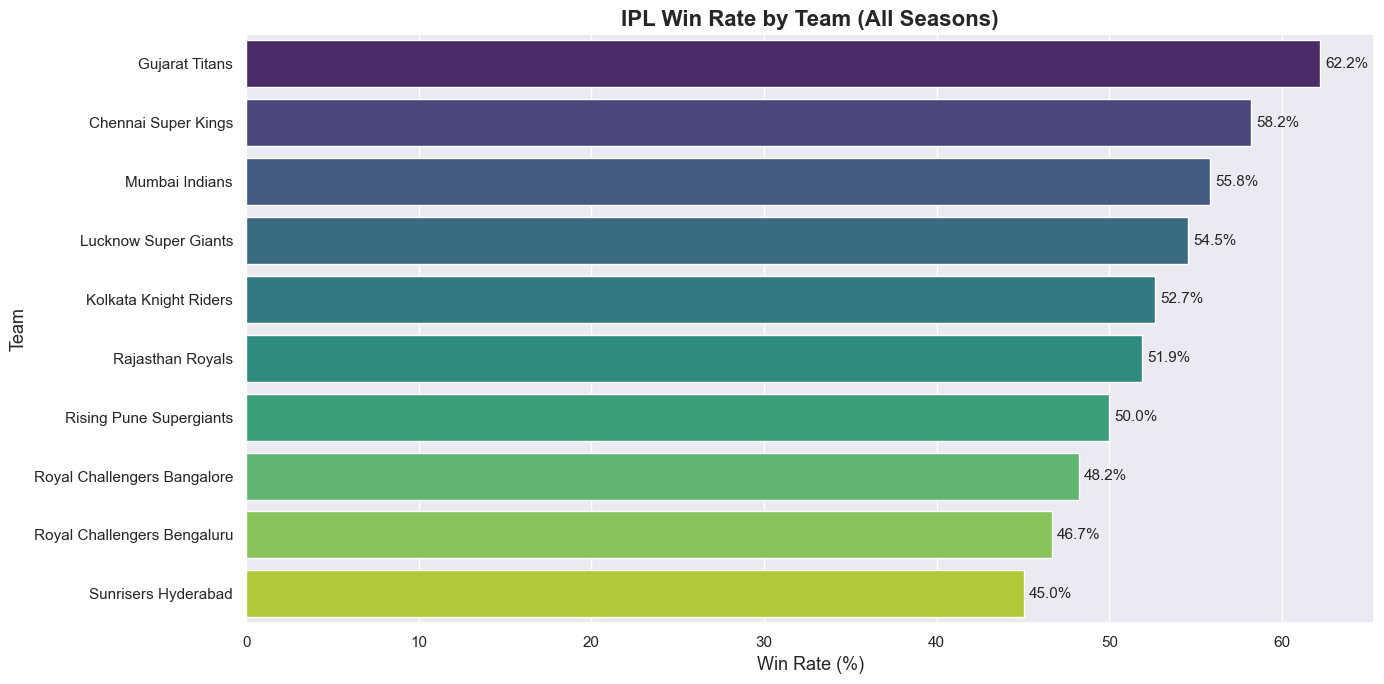

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

bars = sns.barplot(
    data=win_rate.head(10),
    x='win_rate', y='team',
    palette='viridis', ax=ax
)

for bar in bars.patches:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center', fontsize=11
    )

ax.set_title('IPL Win Rate by Team (All Seasons)', fontsize=16, fontweight='bold')
ax.set_xlabel('Win Rate (%)', fontsize=13)
ax.set_ylabel('Team', fontsize=13)
plt.tight_layout()
plt.savefig('chart1_win_rate.png', dpi=150)
plt.show()

### Chart 2 — Toss Decision vs Match Outcome

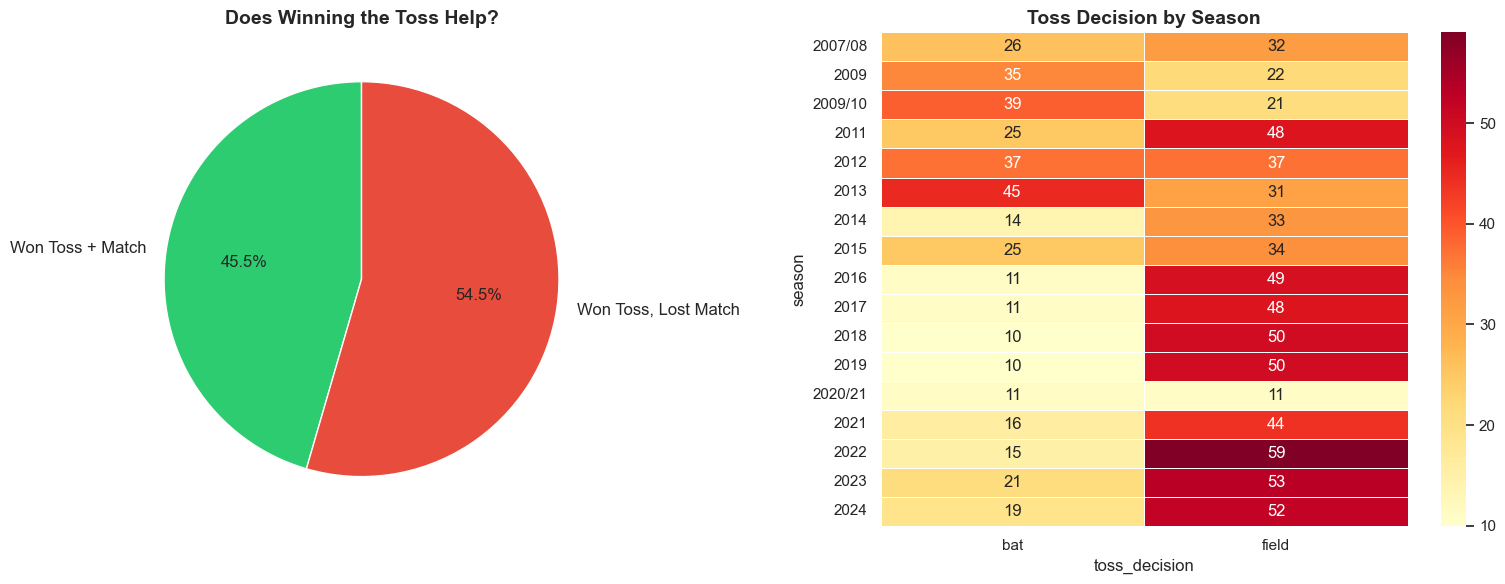

In [6]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']].shape[0]
toss_win_match_lose = matches[matches['toss_winner'] != matches['winner']].shape[0]

pivot = matches.groupby(['season', 'toss_decision']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(
    [toss_win_match_win, toss_win_match_lose],
    labels=['Won Toss + Match', 'Won Toss, Lost Match'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Does Winning the Toss Help?', fontsize=14, fontweight='bold')

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Toss Decision by Season', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_toss.png', dpi=150)
plt.show()

### Chart 3 — Top 10 Run Scorers

In [7]:
top_batsmen = (
    deliveries.groupby('batsman')['batsman_runs']
    .sum().reset_index()
    .sort_values('batsman_runs', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(13, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_batsmen)))
bars = ax.barh(top_batsmen['batsman'], top_batsmen['batsman_runs'], color=colors)

for bar in bars:
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va='center', fontsize=11
    )

ax.set_title('Top 10 Run Scorers in IPL History', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Runs', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart3_top_batsmen.png', dpi=150)
plt.show()

KeyError: 'batsman'

In [8]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


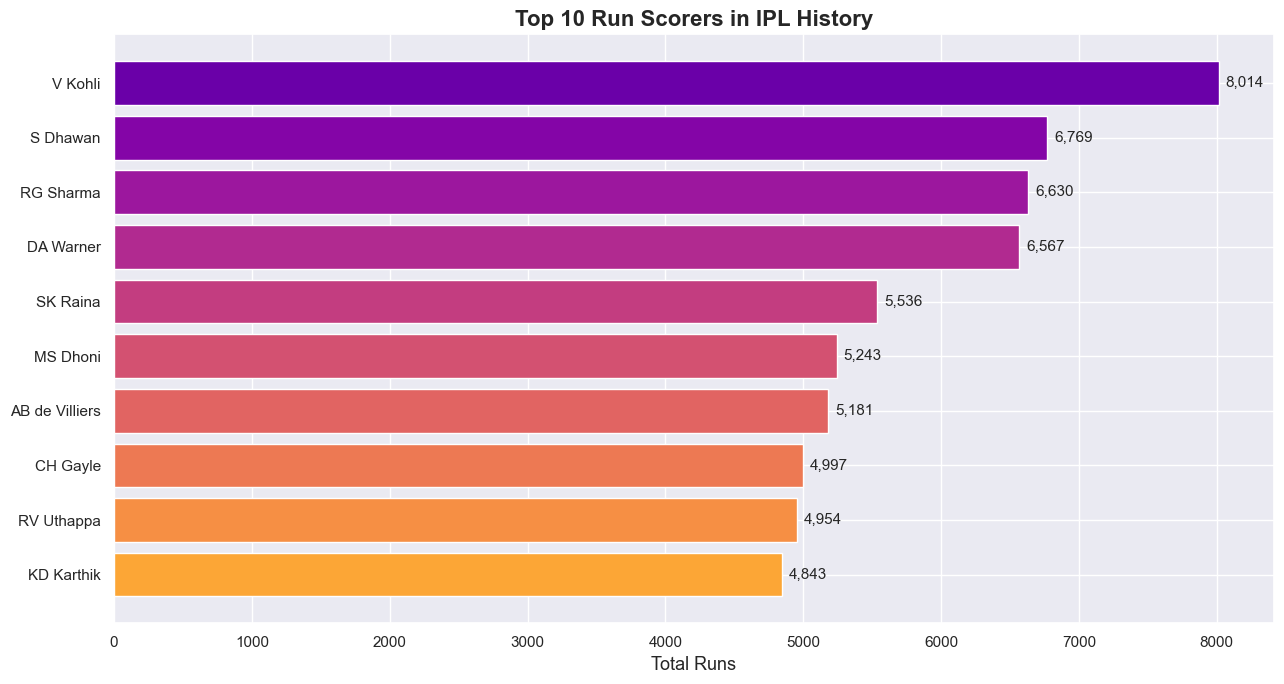

In [9]:
top_batsmen = (
    deliveries.groupby('batter')['batsman_runs']
    .sum().reset_index()
    .sort_values('batsman_runs', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(13, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_batsmen)))
bars = ax.barh(top_batsmen['batter'], top_batsmen['batsman_runs'], color=colors)

for bar in bars:
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va='center', fontsize=11
    )

ax.set_title('Top 10 Run Scorers in IPL History', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Runs', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart3_top_batsmen.png', dpi=150)
plt.show()

## 4. SQL Analysis

In [10]:
conn = sqlite3.connect(':memory:')
matches.to_sql('matches', conn, index=False, if_exists='replace')
deliveries.to_sql('deliveries', conn, index=False, if_exists='replace')

print("SQL database ready!")

SQL database ready!


In [11]:
query1 = """
SELECT winner AS team, COUNT(*) AS total_wins
FROM matches
WHERE winner != 'No Result'
GROUP BY winner
ORDER BY total_wins DESC
LIMIT 8;
"""
pd.read_sql_query(query1, conn)

,team,total_wins
0,Mumbai Indians,139
1,Chennai Super Kings,131
2,Kolkata Knight Riders,128
3,Sunrisers Hyderabad,109
4,Royal Challengers Bangalore,109
5,Rajasthan Royals,109
6,Delhi Capitals,106
7,Kings XI Punjab,79


In [12]:
query2 = """
SELECT 
    batter,
    SUM(batsman_runs) AS total_runs,
    COUNT(DISTINCT match_id) AS innings,
    ROUND(CAST(SUM(batsman_runs) AS FLOAT) / COUNT(DISTINCT match_id), 2) AS average
FROM deliveries
GROUP BY batter
HAVING innings >= 20
ORDER BY average DESC
LIMIT 10;
"""
pd.read_sql_query(query2, conn)

,batter,total_runs,innings,average
0,DP Conway,924,22,42.00
1,B Sai Sudharsan,1034,25,41.36
2,KL Rahul,4689,122,38.43
3,LMP Simmons,1079,29,37.21
4,RD Gaikwad,2380,65,36.62
5,SE Marsh,2489,69,36.07
6,DA Warner,6567,184,35.69
7,CH Gayle,4997,141,35.44
8,ML Hayden,1107,32,34.59
9,MEK Hussey,1977,58,34.09


In [13]:
query3 = """
SELECT 
    m.season,
    SUM(CASE WHEN d.batsman_runs = 6 THEN 1 ELSE 0 END) AS total_sixes
FROM deliveries d
JOIN matches m ON d.match_id = m.id
GROUP BY m.season
ORDER BY total_sixes DESC;
"""
pd.read_sql_query(query3, conn)

,season,total_sixes
0,2024,1261
1,2023,1124
2,2022,1062
3,2018,872
4,2019,786
5,2012,733
6,2017,706
7,2015,692
8,2021,687
9,2013,681
